In [421]:
def get_pre_prevalence(age_matrix_vec, diabetes_mat_list, k):
    """
    Calculate diabetes prevalence for each ethnicity-gender group and age-specific prevalence.

    Parameters:
        age_matrix_vec (list): List of age matrices for different groups.
        diabetes_mat_list (list): List of diabetes matrices for different groups.
        k (int): Column index to use for ages in age_matrix_vec.

    Returns:
        numpy.ndarray: Final diabetes prevalence results.
    """
    import numpy as np

    # Define age groups
    age_groups = [(18, 29), (30, 39), (40, 49), (50, 59), (60, 69), (70, 74)]

    # Initialize matrices for diabetes
    diabetes_total_counts_mat = np.zeros((8, 6))  # Number of people in each age group
    diabetes_counts_mat = np.zeros((8, 6))  # Number of diabetic people in each age group
    pre_diabetes_prevalence_ls = []  # Prevalence for each ethnicity-gender group

    # Iterate over each ethnicity-gender group
    for idx in range(8):
        last_col_ages = age_matrix_vec[idx][:, k]  # Column k of age matrix
        last_col_diabetes = diabetes_mat_list[idx][:, k]  # Column k of diabetes matrix

        # Compute overall diabetes prevalence for idx
        mask_all = (last_col_ages >= 18) & (last_col_ages <= 74)
        total_people = np.sum(mask_all)
        pre_diabetic_people = np.sum(last_col_diabetes[mask_all] == 0.5)

        # Store diabetes prevalence (avoid division by zero)
        pre_diabetes_prevalence_ls.append(pre_diabetic_people / total_people if total_people > 0 else 0)

        # Assign people to age groups and count
        for group_idx, (lower, upper) in enumerate(age_groups):
            mask = (last_col_ages >= lower) & (last_col_ages <= upper)

            diabetes_total_counts_mat[idx, group_idx] = np.sum(mask)  # Total people in age group
            diabetes_counts_mat[idx, group_idx] = np.sum(last_col_diabetes[mask] == 1)  # Diabetic people in age group

    # Exclude "others" if necessary
    pre_diabetes_prevalence_ls = pre_diabetes_prevalence_ls[:6]

    # Compute age-specific diabetes prevalence
    diabetes_age_specific_prevalence = np.divide(
        diabetes_counts_mat.sum(axis=0),
        diabetes_total_counts_mat.sum(axis=0),
        out=np.zeros_like(diabetes_counts_mat.sum(axis=0)),  # Avoid division by zero
        where=diabetes_total_counts_mat.sum(axis=0) > 0
    )

    # Concatenate the final results for diabetes
    pre_diabetes_final_result = np.concatenate([pre_diabetes_prevalence_ls, diabetes_age_specific_prevalence])

    return pre_diabetes_final_result



In [ ]:
def get_prevalence(age_matrix_vec, diabetes_mat_list, k):
    """
    Calculate diabetes prevalence for each ethnicity-gender group and age-specific prevalence.

    Parameters:
        age_matrix_vec (list): List of age matrices for different groups.
        diabetes_mat_list (list): List of diabetes matrices for different groups.
        k (int): Column index to use for ages in age_matrix_vec.

    Returns:
        numpy.ndarray: Final diabetes prevalence results.
    """
    import numpy as np

    # Define age groups
    age_groups = [(18, 29), (30, 39), (40, 49), (50, 59), (60, 69), (70, 74)]

    # Initialize matrices for diabetes
    diabetes_total_counts_mat = np.zeros((8, 6))  # Number of people in each age group
    diabetes_counts_mat = np.zeros((8, 6))  # Number of diabetic people in each age group
    diabetes_prevalence_ls = []  # Prevalence for each ethnicity-gender group

    # Iterate over each ethnicity-gender group
    for idx in range(8):
        last_col_ages = age_matrix_vec[idx][:, k]  # Column k of age matrix
        last_col_diabetes = diabetes_mat_list[idx][:, k]  # Column k of diabetes matrix

        # Compute overall diabetes prevalence for idx
        mask_all = (last_col_ages >= 18) & (last_col_ages <= 74)
        total_people = np.sum(mask_all)
        diabetic_people = np.sum(last_col_diabetes[mask_all] == 1)

        # Store diabetes prevalence (avoid division by zero)
        diabetes_prevalence_ls.append(diabetic_people / total_people if total_people > 0 else 0)

        # Assign people to age groups and count
        for group_idx, (lower, upper) in enumerate(age_groups):
            mask = (last_col_ages >= lower) & (last_col_ages <= upper)

            diabetes_total_counts_mat[idx, group_idx] = np.sum(mask)  # Total people in age group
            diabetes_counts_mat[idx, group_idx] = np.sum(last_col_diabetes[mask] == 1)  # Diabetic people in age group

    # Exclude "others" if necessary
    diabetes_prevalence_ls = diabetes_prevalence_ls[:6]

    # Compute age-specific diabetes prevalence
    diabetes_age_specific_prevalence = np.divide(
        diabetes_counts_mat.sum(axis=0),
        diabetes_total_counts_mat.sum(axis=0),
        out=np.zeros_like(diabetes_counts_mat.sum(axis=0)),  # Avoid division by zero
        where=diabetes_total_counts_mat.sum(axis=0) > 0
    )

    # Concatenate the final results for diabetes
    diabetes_final_result = np.concatenate([diabetes_prevalence_ls, diabetes_age_specific_prevalence])

    return diabetes_final_result




In [422]:
def get_prevalence(age_matrix_vec, diabetes_mat_list, k):
    """
    Calculate diabetes prevalence for each ethnicity-gender group and age-specific prevalence.

    Parameters:
        age_matrix_vec (list): List of age matrices for different groups.
        diabetes_mat_list (list): List of diabetes matrices for different groups.
        k (int): Column index to use for ages in age_matrix_vec.

    Returns:
        numpy.ndarray: Final diabetes prevalence results.
    """
    import numpy as np

    # Define age groups
    age_groups = [(18, 29), (30, 39), (40, 49), (50, 59), (60, 69), (70, 74)]

    # Initialize matrices for diabetes
    diabetes_total_counts_mat = np.zeros((8, 6))  # Number of people in each age group
    diabetes_counts_mat = np.zeros((8, 6))  # Number of diabetic people in each age group
    diabetes_prevalence_ls = []  # Prevalence for each ethnicity-gender group

    # Iterate over each ethnicity-gender group
    for idx in range(8):
        last_col_ages = age_matrix_vec[idx][:, k]  # Column k of age matrix
        last_col_diabetes = diabetes_mat_list[idx][:, k]  # Column k of diabetes matrix

        # Compute overall diabetes prevalence for idx
        mask_all = (last_col_ages >= 18) & (last_col_ages <= 74)
        total_people = np.sum(mask_all)
        diabetic_people = np.sum(last_col_diabetes[mask_all] == 1)

        # Store diabetes prevalence (avoid division by zero)
        diabetes_prevalence_ls.append(diabetic_people / total_people if total_people > 0 else 0)

        # Assign people to age groups and count
        for group_idx, (lower, upper) in enumerate(age_groups):
            mask = (last_col_ages >= lower) & (last_col_ages <= upper)

            diabetes_total_counts_mat[idx, group_idx] = np.sum(mask)  # Total people in age group
            diabetes_counts_mat[idx, group_idx] = np.sum(last_col_diabetes[mask] == 1)  # Diabetic people in age group

    # Exclude "others" if necessary
    diabetes_prevalence_ls = diabetes_prevalence_ls[:6]

    # Compute age-specific diabetes prevalence
    diabetes_age_specific_prevalence = np.divide(
        diabetes_counts_mat.sum(axis=0),
        diabetes_total_counts_mat.sum(axis=0),
        out=np.zeros_like(diabetes_counts_mat.sum(axis=0)),  # Avoid division by zero
        where=diabetes_total_counts_mat.sum(axis=0) > 0
    )

    # Concatenate the final results for diabetes
    diabetes_final_result = np.concatenate([diabetes_prevalence_ls, diabetes_age_specific_prevalence])

    return diabetes_final_result




In [1]:
import numpy as np
from scipy.stats import norm


def calculate_bmi(ages, yearborn, index, bmitable, height=170.0):
    """
    Calculate BMI based on age, year of birth, index, and a BMI table.

    Parameters:
        ages (int): The age of the individual.
        yearborn (int): The year the individual was born.
        index (int): The index used to access specific rows in the bmitable.
        bmitable (numpy.ndarray): A 2D array containing the necessary coefficients and hyperparameters.
        height (float): The height of the individual in centimeters (default is 170 cm).

    Returns:
        float: The calculated BMI value.
    """
    # Generate random numbers from a normal distribution
    rng = norm.rvs(loc=0, scale=1, size=4)

    # Calculate hyperparameters
    M1 = bmitable[index, 0] + bmitable[index, 6] * rng[0]
    M2 = bmitable[index, 1] + bmitable[index, 7] * rng[0] + bmitable[index, 8] * rng[1]
    M3 = bmitable[index, 2] + bmitable[index, 9] * rng[0] + bmitable[index, 10] * rng[1] + bmitable[index, 11] * rng[2]
    M4 = bmitable[index, 3] + bmitable[index, 12] * rng[0] + bmitable[index, 13] * rng[1] + bmitable[index, 14] * rng[2] + bmitable[index, 15] * rng[3]

    # Calculate coefficients
    y0 = M2 + bmitable[index, 4] * (yearborn - 1950) + M1 * (35 - 18)
    y1 = M2 + bmitable[index, 4] * (yearborn - 1950)
    y2 = M2 + bmitable[index, 4] * (yearborn - 1950) + M3 * (55 - 35)
    y3 = M2 + bmitable[index, 4] * (yearborn - 1950) + M3 * (55 - 35) + M4 * (75 - 55)
    m1 = 6 * (0.014492754 * ((y2 - y1) / 20 - (y1 - y0) / 17) - 0.003623188 * ((y3 - y2) / 20 - (y2 - y1) / 20))
    m2 = 6 * (-0.003623188 * ((y2 - y1) / 20 - (y1 - y0) / 17) + 0.013405797 * ((y3 - y2) / 20 - (y2 - y1) / 20))
    b0 = (y1 - y0) / 17 - 17 / 6 * m1
    b1 = (y2 - y1) / 20 - 10 * m1 - 20 / 6 * (m2 - m1)
    b2 = (y3 - y2) / 20 - 10 * m2 + 20 / 6 * m2
    d0 = m1 / (6 * 17)
    d1 = (m2 - m1) / (6 * 20)
    d2 = (-m2) / (6 * 20)

    # Calculate BMI based on age
    # Define conditions
    cond1 = ages > 80
    cond2 = (ages >= 55) & (ages <= 80)
    cond3 = (ages >= 35) & (ages < 55)
    cond4 = (ages >= 0) & (ages < 35)
    cond6 = ages == -1

    # Define corresponding calculations for each condition
    bmi_values = np.select(
        [cond1, cond2, cond3, cond4],# cond6
        [
            0,  # Condition: age > 80
            y2 + b2 * (ages - 55) + d2 * np.power(ages - 55, 3) + m2 / 2 * np.power(ages - 55, 2),
            y1 + b1 * (ages - 35) + d1 * np.power(ages - 35, 3) + m1 / 2 * np.power(ages - 35, 2),
            y0 + b0 * (ages - 18) + d0 * np.power(ages - 18, 3),
            # y0 + b0 * (18 - 18) + d0 * np.power(18 - 18, 3),
            # -1  # Condition: age == -1
        ],
        default=np.nan  # Optional: handle unexpected cases with NaN
    )

    # Apply random noise to the BMI value
    #thisbmi = np.exp(norm.rvs(loc=thisbmi, scale=bmitable[index, 5], size=1)[0])
    scales = bmitable[index, 5]  # Get scale values for the corresponding row

    # Generate random samples from normal distribution and apply exponential transformation
   # bmi_transformed = np.exp(norm.rvs(loc=bmi_values, scale=scales, size=bmi_values.shape))
    bmi_transformed = np.where(ages == -1, -1, np.exp(norm.rvs(loc=bmi_values, scale=scales, size=bmi_values.shape)))

    return bmi_transformed

## diabetes 

In [2]:
def schedule_pre_diabetes_probability(age_mat, i, bmi_mat):
    beta = 0.18
    theta = np.array([
        -10.73568597 * 1.01,
        -11.11297803 * 0.98,
        -10.594319 * 1.02,
        -10.97161203 * 1.02,
        -10.15266278 * 1.0,
        -10.52995483 * 1.02,
        -10.73568597,
        -11.11297803
    ])
    
    # age = np.asarray(age)
    # bmi = np.asarray(bmi)
    
    # Create the output array
    prob = np.zeros_like(age_mat, dtype=float)
    
    # Set invalid values first
    prob[age_mat == -1] = -1
    
    # Set <18 to 0
    prob[(age_mat < 18) & (age_mat != -1)] = 0
    
    # Set 18 <= age < 25 to 0.0001
    mask_18_25 = (age_mat >= 18) & (age_mat < 25)
    prob[mask_18_25] = 0.002
    
    # For age >= 25, apply logistic regression formula
    mask = (age_mat >= 25) 
    
    alpha = np.where(age_mat[mask] < 70, 0.045, 0.04)
    linear_term = theta[i] + alpha * age_mat[mask] + beta * bmi_mat[mask]
    prob[mask] = 1 - 1 / (1 + np.exp(linear_term))
    
    return prob


def schedule_diabetes_probability(age_mat, i, bmi_mat):
    beta = 0.19
    theta = np.array([
        -10.73568597 * 1.0,
        -11.11297803 * 0.97,
        -10.59431997 * 1.,
        -10.971612 * 1.01,
        -10.15266278 * 1.0,
        -10.52995483 * 1.03,
        -10.59431997 * 1.01,
        -10.971612 * 1.01,
    ])
    
    # Create the output array
    prob = np.zeros_like(age_mat, dtype=float)
    
    # Set invalid values first
    prob[age_mat == -1] = -1
    
    # Set <25 to 0.00015
    mask_25 = (age_mat < 25) & (age_mat != -1)
    prob[mask_25] = 0.002
    
    # For age >= 25, apply logistic regression formula
    mask = (age_mat >= 25)
    
    alpha = np.where(age_mat[mask] < 70, 0.045, 0.035)
    linear_term = theta[i] + alpha * age_mat[mask] + beta * bmi_mat[mask]
    prob[mask] = 1 - 1 / (1 + np.exp(linear_term))
    
    return prob

coeffcient increase, prob decrease 

## age and BMI loading 

In [16]:
from collections import defaultdict
import numpy as np

# Assuming bmitable.csv is in the current directory
file_path = '../data/bmitable.csv'

# Load the CSV file into a numpy array
bmitable = np.genfromtxt(file_path, delimiter=',', skip_header=1)

# Display the shape of the array (optional)
print("Shape of bmitable:", bmitable.shape)

Shape of bmitable: (8, 16)


In [7]:
import os
import numpy as np
import pandas as pd

# List to store the NumPy arrays (equivalent to std::vector<ArrayXXi> in C++)
age_matrix_vec = []

# Number of files to read
num_files = 8  # Change this to the actual number of files to read

path = "/Users/haolong/Documents/demos_v_matrix/output/"
for i in range(num_files):
    # Create the filename dynamically

    filename = f"popu_matrix_{i}.csv"
    matrix = pd.read_csv(path + filename).to_numpy() # convert to numpy
    
    
    filtered_matrix = matrix[~np.all(matrix < 0, axis=1)]
    age_matrix_vec.append(filtered_matrix)

### BMI loading 

In [ ]:
age_matrix_vec[0]

In [ ]:

def apply_bmi(row, idx):
    """Compute BMI using calculate_bmi, with yearborn based on the first nonzero index."""
    first_nonzero_idx = np.where(row >= 0)[0][0] # Find first nonnegative index
    first_nonzero_value = row[first_nonzero_idx]
    yearborn = 1989 + first_nonzero_idx - first_nonzero_value
    
    bmi_values = calculate_bmi(row, yearborn, idx, bmitable) 
    # print(f"Shape of returned BMI values: {bmi_values.shape}") 
    # print(f"year: {yearborn}")
    return calculate_bmi(row, yearborn, idx, bmitable)  # Use idx instead of 0

# Initialize bmi_matrix


bmi_matrix_ls = [] 
# Iterate over age_matrix_vec
for idx in range(8):
    matrix = age_matrix_vec[idx]  # Extract the matrix
    bmi_matrix = np.zeros_like(matrix, dtype=float)
    temp = np.apply_along_axis(lambda row: apply_bmi(row, idx), 1, matrix)  # Apply function row-wise
    bmi_matrix = temp
    bmi_matrix_ls.append(bmi_matrix)


# parent_dir = "../data/bmi_matrix"
# for idx, matrix in enumerate(bmi_matrix_ls):
#     file_path = os.path.join(parent_dir, f"bmi_matrix_{idx}.npy")
#     np.save(file_path, matrix)
#     print(f"Saved: {file_path}")

In [5]:
age_matrix_vec[0]

NameError: name 'age_matrix_vec' is not defined

In [ ]:
bmi_matrix_ls = [] 
# Iterate over age_matrix_vec
for idx in range(8):
    matrix = age_matrix_vec[idx]  # Extract the matrix
    bmi_matrix = np.zeros_like(matrix, dtype=float)
    temp = np.apply_along_axis(lambda row: apply_bmi(row, idx), 1, matrix)  # Apply function row-wise
    bmi_matrix = temp
    bmi_matrix_ls.append(bmi_matrix)


parent_dir = "../data/bmi_matrix"
for idx, matrix in enumerate(bmi_matrix_ls):
    file_path = os.path.join(parent_dir, f"bmi_matrix_{idx}.npy")
    np.save(file_path, matrix)
    print(f"Saved: {file_path}")

In [4]:
N = 8 
parent_dir = "../data/bmi_matrix" 
bmi_matrix_ls = []
for idx in range(N):
    file_path = os.path.join(parent_dir, f"bmi_matrix_{idx}.npy")
    matrix = np.load(file_path)
    bmi_matrix_ls.append(matrix)


NameError: name 'os' is not defined

### Main code for diabetes 

deal with 1990 first and then 

In [8]:

age_dict = [{} for _ in range(N)]
for i in range(N):
    ages = age_matrix_vec[i][:,0]
    # convert ages to
    for age in ages:
        if age >= 18 and age <= 74:
            if age not in age_dict[i]:
                age_dict[i][age] = 1
            else:
                age_dict[i][age] += 1

bmi_samples_dict = {}

## small task 

save matrices to dictionary. 

In [14]:
age_dict[0][18]

922

In [15]:
for group in range(N):
    bmi_samples_dict[group] = {}
    for key, value in age_dict[group].items():
        age = key
        age_vector = np.arange(18, key + 1)
        year_born = 1990 - key 
        # Repeat the BMI calculation for 'value' times
        bmi_samples = np.array([calculate_bmi(age_vector, year_born, group, bmitable, height=170.0) for _ in range(value)])
        bmi_samples_dict[group][age] = bmi_samples


          

NameError: name 'bmitable' is not defined

In [475]:
# for group in range(N):
#      for key, bmi_samples in bmi_samples_dict[group].items():
#         save_dir = "../data/bmi_samples"
#         os.makedirs(save_dir, exist_ok=True)
#         save_path = os.path.join(save_dir, f"bmi_samples_group{group}_age{key}.npy")
#         np.save(save_path, bmi_samples)

save_dir = "../data/bmi_samples"
os.makedirs(save_dir, exist_ok=True)
for group in range(N):
    for key, value in bmi_samples_dict[group].items():
        save_path = os.path.join(save_dir, f"bmi_samples_group{group}_age{key}.npy")
        np.save(save_path, value)

bmi_samples_dict = {}

for group in range(N):
    bmi_samples_dict[group] = {}
    for age in age_dict[group]:
        file_path = f"../data/bmi_samples/bmi_samples_group{group}_age{age}.npy"
        try:
            bmi_samples = np.load(file_path)
            bmi_samples_dict[group][age] = bmi_samples
        except FileNotFoundError:
            print(f"File not found: {file_path}")

In [ ]:
# get 1990 

diabetes_status_dict = {}
diabetes_mat_list = []
for group in range(N):
        i = group
        diabetes_status_dict[group] = {}
        diabetes_status = np.zeros((age_matrix_vec[i].shape[0], age_matrix_vec[i].shape[1]))  
        for age in age_dict[group]:
                bmi_samples = bmi_samples_dict[group][age]  # shape: (n_samples, n_ages)
                n_samples, n_ages = bmi_samples.shape
                # Create an age matrix with shape (n_samples, n_ages)
                age_mat = np.tile(np.arange(18, age + 1), (n_samples, 1))
                # idx = group

                # Compute prediabetes probability matrix
                prediabetes_prob_matrix = schedule_pre_diabetes_probability(age_mat,i,bmi_samples)
                rand_matrix = np.random.rand(*bmi_samples.shape)
                prediabetes_matrix = (rand_matrix < prediabetes_prob_matrix) * 0.5
                prediabetes_matrix = np.maximum.accumulate(prediabetes_matrix, axis=1)

                # Compute diabetes probability matrix
                diabetes_prob_matrix = schedule_diabetes_probability(age_mat,i,bmi_samples)
                rand_matrix = np.random.rand(*bmi_samples.shape)
                diabetes_matrix = np.where(rand_matrix < diabetes_prob_matrix, 1, 0.5)

                # Combine: take max along each row (for each sample)
                combined_matrix = np.where(prediabetes_matrix == 0.5, diabetes_matrix, prediabetes_matrix)
                combined_matrix = np.maximum.accumulate(combined_matrix, axis=1)

                diabetes_status_dict[group][age] = np.max(combined_matrix, axis=1)
        


In [479]:
# First shape is n_samples (88417), second shape is from age_matrix_vec[i]


# Method 1: Using np.tile with reshape
diabetes_status = np.tile(diabetes_status[:, 0][:, np.newaxis], (1, n_cols))

# Or Method 2: Using np.repeat (alternative approach)
diabetes_status = np.repeat(diabetes_status[:, 0][:, np.newaxis], n_cols, axis=1)

In [480]:
diabetes_mat_list = []
prediabetes_mat_list = []
for i in range(8):
        diabetes_status = np.zeros((age_matrix_vec[i].shape[0], age_matrix_vec[i].shape[1] ))  
        for age, status_vec in diabetes_status_dict[i].items():
            # Find positions where the first column of age_matrix_vec[i] equals 'age'
            positions = np.where(age_matrix_vec[i][:, 0] == age)[0]
            # Assign the diabetes status vector for this age group
            diabetes_status[positions, 0] = status_vec

        n_cols = age_matrix_vec[i].shape[1]
        diabetes_status_before = np.repeat(diabetes_status[:, 0][:, np.newaxis], n_cols, axis=1)
        # Process diabetes status
        bmi_mat = bmi_matrix_ls[i]
        age_mat = age_matrix_vec[i]

        prediabetes_prob_matrix = schedule_pre_diabetes_probability(age_mat, i, bmi_mat)
        rand_matrix = np.random.rand(*age_mat.shape)
        prediabetes_matrix = (rand_matrix < prediabetes_prob_matrix) * 0.5
        
        prediabetes_matrix = np.where(diabetes_status_before == 0, prediabetes_matrix, diabetes_status_before)
        prediabetes_matrix = np.maximum.accumulate(prediabetes_matrix, axis=1)
        prediabetes_mat_list.append(prediabetes_matrix)
        
        diabetes_prob_matrix = schedule_diabetes_probability(age_mat, i, bmi_mat)
        rand_matrix = np.random.rand(*age_mat.shape)
        diabetes_matrix = np.where(rand_matrix < diabetes_prob_matrix, 1, 0.5)
        
        combined_matrix = np.where(prediabetes_matrix == 0.5, diabetes_matrix, prediabetes_matrix)

        diabetes_status[:, 1:] = combined_matrix[:, 1:]
        diabetes_status = np.maximum.accumulate(diabetes_status, axis=1)
        diabetes_mat_list.append(diabetes_status)
    

In [482]:
diabetes_final_result = get_prevalence(age_matrix_vec,diabetes_mat_list,-2)

In [483]:
pre_diabetes_final_result = get_pre_prevalence(age_matrix_vec,prediabetes_mat_list,-2)

In [484]:
pre_diabetes_final_result

array([2.32633140e-01, 1.80353447e-01, 2.64705882e-01, 2.50092799e-01,
       3.58877776e-01, 3.00521788e-01, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 9.66588266e-05, 4.42414728e-03, 1.41725719e-02])

In [485]:
diabetes_final_result * 100

array([ 8.48337472,  5.81250205, 13.17498608, 12.6484781 , 19.39212885,
       14.79340008,  0.07893179,  1.10100682,  4.54633267, 11.33808036,
       21.21093193, 28.85577324])

In [486]:
targeting_diabeteslist = np.array([ 8.2, 5.8, 13.5, 12.4, 19.1, 14.4, 0.2 , 1.9, 5.0, 10.8, 21.8, 24.2])

## save results to diabetes_matrix 

In [501]:
# Create the directory if it doesn't exist
save_dir = "../data/diabetes_matrix"
os.makedirs(save_dir, exist_ok=True)

# Save each matrix in diabetes_mat_list
for i, diabetes_mat in enumerate(diabetes_mat_list):
    save_path = os.path.join(save_dir, f"diabetes_mat_{i}.npy")
    np.save(save_path, diabetes_mat)
    print(f"Saved: {save_path}")

Saved: ../data/diabetes_matrix/diabetes_mat_0.npy
Saved: ../data/diabetes_matrix/diabetes_mat_1.npy
Saved: ../data/diabetes_matrix/diabetes_mat_2.npy
Saved: ../data/diabetes_matrix/diabetes_mat_3.npy
Saved: ../data/diabetes_matrix/diabetes_mat_4.npy
Saved: ../data/diabetes_matrix/diabetes_mat_5.npy
Saved: ../data/diabetes_matrix/diabetes_mat_6.npy
Saved: ../data/diabetes_matrix/diabetes_mat_7.npy


In [ ]:
# Load the diabetes_mat_0.npy file
diabetes_mat_0 = np.load("../data/diabetes_matrix/diabetes_mat_0.npy")
# Print the shape of the loaded matrix
print("Shape of diabetes_mat_0:", diabetes_mat_0.shape)
# Assert the shape of diabetes_mat_0
assert diabetes_mat_0.shape == (88417, 34), f"Expected shape (88417, 34), but got {diabetes_mat_0.shape}"

Shape of diabetes_mat_0: (88417, 34)


## validation plots 

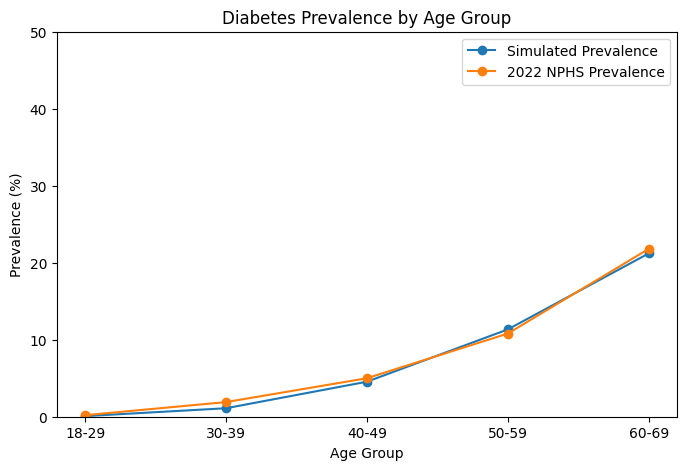

In [487]:
import matplotlib.pyplot as plt
import numpy as np
import os


age_labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70-74"]


# Extracting relevant slices
simulated_prevalence = diabetes_final_result[6:11] * 100
nphs_prevalence = targeting_diabeteslist[6:11] 
age_labels = age_labels[:-1]
# Plotting
plt.figure(figsize=(8, 5))

plt.plot(age_labels, simulated_prevalence, marker='o', linestyle='-', label="Simulated Prevalence", markersize=6)
plt.plot(age_labels, nphs_prevalence, marker='o', linestyle='-', label="2022 NPHS Prevalence", markersize=6)
plt.ylim(0,50)
plt.xlabel("Age Group")
plt.ylabel("Prevalence (%)")
plt.title("Diabetes Prevalence by Age Group")
plt.legend()


# Create the directory if it doesn't exist
plots_dir = "plots"
os.makedirs(plots_dir, exist_ok=True)

# Save the plot
plot_path = os.path.join(plots_dir, "Diabetes_2022.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

plt.show()

### hard to explain 3% difference 
## test 

initialize a 20 - 40 age old matrix 

In [488]:

# initialize a 100 * 20 matrix
# start year 1990 

age_vector = np.arange(30, 50)
year_born = 2021 - 50 
i = 0 
n = 100
bmi_samples = np.array([calculate_bmi(age_vector, year_born, i, bmitable, height=170.0) for _ in range(100)])




In [489]:
age_mat = np.tile( age_vector,(100,1))

In [490]:
age_mat

array([[30, 31, 32, ..., 47, 48, 49],
       [30, 31, 32, ..., 47, 48, 49],
       [30, 31, 32, ..., 47, 48, 49],
       ...,
       [30, 31, 32, ..., 47, 48, 49],
       [30, 31, 32, ..., 47, 48, 49],
       [30, 31, 32, ..., 47, 48, 49]])

## method 1 : 18 - 30 first, and then 30 - 50 


In [491]:
np.random.seed(42)

In [492]:
n_samples = 5000
age_mat = np.tile(np.arange(18, 40), (n_samples, 1))
age_vector = np.arange(18,40)
year_born = 2021 - 40 

bmi_samples_total = np.array([calculate_bmi(age_vector, year_born, i, bmitable, height=170.0) for _ in range(n_samples)])
# Generate all random matrices once
rand_matrix_pred = np.random.rand(n_samples, len(age_vector))
rand_matrix_diab = np.random.rand(n_samples, len(age_vector))

In [493]:
# do it with 18 - 30 first, and then 30 - 50 

bmi_samples = bmi_samples_total[:,:12]
# Compute prediabetes probability matrix
age_mat = np.tile(np.arange(18, 30), (n_samples, 1))
age_vector = np.arange(18,30)

prediabetes_prob_matrix = schedule_pre_diabetes_probability(age_mat,i,bmi_samples)
rand_matrix = rand_matrix_pred[:,:12]
prediabetes_matrix = (rand_matrix < prediabetes_prob_matrix) * 0.5
prediabetes_matrix = np.maximum.accumulate(prediabetes_matrix, axis=1)

# Compute diabetes probability matrix
diabetes_prob_matrix = schedule_diabetes_probability(age_mat,i,bmi_samples)
rand_matrix = rand_matrix_diab[:,:12]
diabetes_matrix = np.where(rand_matrix < diabetes_prob_matrix, 1, 0.5)

# Combine: take max along each row (for each sample)
combined_matrix_1 = np.where(prediabetes_matrix == 0.5, diabetes_matrix, prediabetes_matrix)
combined_matrix_1 = np.maximum.accumulate(combined_matrix_1, axis=1)

diabetes_vec = np.max(combined_matrix_1, axis=1)

# progate along the axis
age_range_length = 40 - 30 
diabetes_mat_befor = np.tile(diabetes_vec, (age_range_length, 1)).T


# get 30 - 50 
age_vector = np.arange(30,40)
age_mat = np.tile(np.arange(30, 40), (n_samples, 1))

bmi_samples = bmi_samples_total[:,12:]
# Compute prediabetes probability matrix
prediabetes_prob_matrix = schedule_pre_diabetes_probability(age_mat,i,bmi_samples)
rand_matrix = rand_matrix_pred[:,12:]
prediabetes_matrix = (rand_matrix < prediabetes_prob_matrix) * 0.5
prediabetes_matrix = np.maximum.accumulate(prediabetes_matrix, axis=1)

combined_matrix = np.where(diabetes_mat_befor == 0, prediabetes_matrix, diabetes_mat_befor)
combined_matrix = np.maximum.accumulate(combined_matrix, axis=1)

# Compute diabetes probability matrix
diabetes_prob_matrix = schedule_diabetes_probability(age_mat,i,bmi_samples)
rand_matrix = rand_matrix_diab[:,12:]
diabetes_matrix = np.where(rand_matrix < diabetes_prob_matrix, 1, 0.5)

# Combine: take max along each row (for each sample)
combined_matrix_2 = np.where(combined_matrix == 0.5, diabetes_matrix, combined_matrix)
combined_matrix_2 = np.maximum.accumulate(combined_matrix_2, axis=1)


#combined_matrix_2 = np.column_stack((diabetes_vec, combined_matrix_2))

diabetes_vec = np.max(combined_matrix_2, axis=1)

diabetes_vec_split = diabetes_vec

pre = (diabetes_vec == 1).sum() / n_samples
print(pre)

0.0214


In [494]:
rows_with_one = np.where(np.any(combined_matrix == 0.5, axis=1))[0]

for idx in rows_with_one:
    print("Row index:", idx)
    print("combined_matrix:", combined_matrix[idx, :])
    # print("age_mat:", age_mat[idx, :])
    # print("bmi_samples:", bmi_samples[idx, :])


Row index: 8
combined_matrix: [0.  0.  0.  0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Row index: 25
combined_matrix: [0.  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Row index: 26
combined_matrix: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Row index: 29
combined_matrix: [0.  0.  0.  0.  0.  0.  0.  0.  0.5 0.5]
Row index: 45
combined_matrix: [0.  0.  0.  0.  0.  0.  0.  0.  0.  0.5]
Row index: 54
combined_matrix: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Row index: 59
combined_matrix: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Row index: 75
combined_matrix: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Row index: 88
combined_matrix: [0.  0.  0.  0.  0.5 0.5 0.5 0.5 0.5 0.5]
Row index: 100
combined_matrix: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Row index: 105
combined_matrix: [0.  0.  0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Row index: 109
combined_matrix: [0.  0.  0.  0.  0.  0.  0.  0.5 0.5 0.5]
Row index: 111
combined_matrix: [0.  0.  0.  0.  0.  0.  0.5 0.5 0.5 0.5]
Row index: 123
combined_matrix: [0.  0.  0.  0. 

In [495]:

# with 18 - 40 directly 


n_samples = 5000
age_mat = np.tile(np.arange(18, 40), (n_samples, 1))

age_vector = np.arange(18,40)
year_born = 2021 - 40 

bmi_samples = bmi_samples_total
# Compute prediabetes probability matrix rand_matrix_pred[:,12:]
prediabetes_prob_matrix = schedule_pre_diabetes_probability(age_mat,i,bmi_samples)
rand_matrix = rand_matrix_pred
prediabetes_matrix = (rand_matrix < prediabetes_prob_matrix) * 0.5
prediabetes_matrix = np.maximum.accumulate(prediabetes_matrix, axis=1)

# Compute diabetes probability matrix
diabetes_prob_matrix = schedule_diabetes_probability(age_mat,i,bmi_samples)
rand_matrix = rand_matrix_diab
diabetes_matrix = np.where(rand_matrix < diabetes_prob_matrix, 1, 0.5)

# Combine: take max along each row (for each sample)
combined_matrix = np.where(prediabetes_matrix == 0.5, diabetes_matrix, prediabetes_matrix)
combined_matrix = np.maximum.accumulate(combined_matrix, axis=1)

diabetes_vec_all = np.max(combined_matrix, axis=1)

pre = (diabetes_vec_all == 1).sum() / n_samples
print(pre)


diff_indices = np.where(diabetes_vec_split != diabetes_vec_all)[0]

for idx in diff_indices[:10]: 
    print(combined_matrix_1[idx,:])
    print(combined_matrix_2[idx,:])
    print(combined_matrix[idx,:12])
    print(combined_matrix[idx,12:])

0.0214


## directly calculate 18 - 74, year 2021 

### step 1: store the population into dictionaries

In [496]:
N = 8

age_dict = [defaultdict(int) for _ in range(N)]
for i in range(N):
    ages = age_matrix_vec[i][:, -2]
    for age in ages:
        if 18 <= age <= 74:
            age_dict[i][age] += 1


### step 2 for population of certain year, generate past year BMI and store them

each age, we will have a BMI matrices; Since all matrices are of different sizes, therefore we can use dictionary or list to store them; with a preference of dictionary. 

In [497]:
target_year = 2021 
for i in range(N):
    for key, value in age_dict[i].items():
        age_vector = np.arange(18, key + 1)
        year_born = target_year - key 
        # Repeat the BMI calculation for 'value' times
        bmi_samples = np.array([calculate_bmi(age_vector, year_born, i, bmitable, height=170.0) for _ in range(value)])
        # Save the results as .npy file
        save_dir = "../data/bmi_samples"
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, f"bmi_samples_group{i}_age{key}.npy")
        np.save(save_path, bmi_samples)

bmi_samples_dict = {}

for group in range(N):
    bmi_samples_dict[group] = {}
    for age in age_dict[group]:
        file_path = f"../data/bmi_samples/bmi_samples_group{group}_age{age}.npy"
        try:
            bmi_samples = np.load(file_path)
            bmi_samples_dict[group][age] = bmi_samples
        except FileNotFoundError:
            print(f"File not found: {file_path}")

### step 3: use BMI to have a 2 step stochastic process

In [498]:
# For each group and age in bmi_samples_dict, calculate diabetes status vector
diabetes_status_dict = {}
diabetes_mat_list = []
for group in range(N):
        i = group
        diabetes_status_dict[group] = {}
        diabetes_status = np.zeros((age_matrix_vec[i].shape[0], age_matrix_vec[i].shape[1]))  
        for age in age_dict[group]:
                bmi_samples = bmi_samples_dict[group][age]  # shape: (n_samples, n_ages)
                n_samples, n_ages = bmi_samples.shape
                # Create an age matrix with shape (n_samples, n_ages)
                age_mat = np.tile(np.arange(18, age + 1), (n_samples, 1))

                # Compute prediabetes probability matrix
                prediabetes_prob_matrix = schedule_pre_diabetes_probability(age_mat,i,bmi_samples)
                rand_matrix = np.random.rand(*bmi_samples.shape)
                prediabetes_matrix = (rand_matrix < prediabetes_prob_matrix) * 0.5
                prediabetes_matrix = np.maximum.accumulate(prediabetes_matrix, axis=1)

                # Compute diabetes probability matrix
                diabetes_prob_matrix = schedule_diabetes_probability(age_mat,i,bmi_samples)
                rand_matrix = np.random.rand(*bmi_samples.shape)
                diabetes_matrix = np.where(rand_matrix < diabetes_prob_matrix, 1, 0.5)

                # Combine: take max along each row (for each sample)
                combined_matrix = np.where(prediabetes_matrix == 0.5, diabetes_matrix, prediabetes_matrix)
                combined_matrix = np.maximum.accumulate(combined_matrix, axis=1)

                diabetes_status_dict[group][age] = np.max(combined_matrix, axis=1)
    

for i in range(8):
    diabetes_status = np.zeros((age_matrix_vec[i].shape[0], age_matrix_vec[i].shape[1]))  
    for age, status_vec in diabetes_status_dict[i].items():
        # Find positions where the first column of age_matrix_vec[i] equals 'age'
        positions = np.where(age_matrix_vec[i][:, -2] == age)[0]
        # Get the diabetes status vector for this age group
        # status_vec = diabetes_status_dict[i][age]
        diabetes_status[positions,-2] = status_vec
    

    diabetes_mat_list.append(diabetes_status)           
                

In [499]:
diabetes_final_result = get_prevalence(age_matrix_vec,diabetes_mat_list,-2)

In [500]:
diabetes_final_result

array([0.08479925, 0.0594718 , 0.13740954, 0.12193764, 0.18807637,
       0.15808772, 0.00085509, 0.01253654, 0.04411102, 0.11708606,
       0.21403596, 0.28678616])